# 🐾 Animal Skin Disease Classifier
Upload an image → see the predicted disease on the image itself.

In [10]:
#CELL 1 — Install (Colab only)
%pip install tensorflow scikit-learn opencv-python-headless matplotlib joblib -q


Note: you may need to restart the kernel to use updated packages.


In [6]:
# CELL 2 — Imports & Config
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import cv2
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre

MODEL_DIR   = 'models'   # Colab: '/content/drive/MyDrive/AnimalDisease/models'
IMG_SIZE    = (224, 224)
W_SVM, W_DNN = 0.4, 0.6

CLASS_NAMES = [
    'Dermatitis', 'Fungal Infections', 'Healthy',
    'Hypersensitivity', 'Demodicosis', 'Ringworm'
]
CLASS_COLORS = {
    'Dermatitis':        '#e74c3c',
    'Fungal Infections': '#8e44ad',
    'Healthy':           '#27ae60',
    'Hypersensitivity':  '#e67e22',
    'Demodicosis':       '#2980b9',
    'Ringworm':          '#c0392b'
}
print('Setup done.')

Setup done.


In [7]:
# CELL 3 — Load Models
print('Loading models...')
resnet = ResNet50(weights='imagenet', include_top=False,
                  pooling='avg', input_shape=(224, 224, 3))
svm    = joblib.load(os.path.join(MODEL_DIR, 'svm_model.pkl'))
scaler = joblib.load(os.path.join(MODEL_DIR, 'scaler.pkl'))
print('Models loaded!')

Loading models...
Models loaded!


In [8]:
# CELL 4 — Predict & Display
def predict_disease(img_path):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError(f'Cannot read: {img_path}')

    # ResNet50 → SVM only (most reliable model)
    r = np.expand_dims(resnet_pre(cv2.resize(img_bgr, IMG_SIZE).astype(np.float32)), 0)
    feats = resnet.predict(r, verbose=0)
    feats_scaled = scaler.transform(feats)
    final = svm.predict_proba(feats_scaled)[0]

    idx = int(np.argmax(final))
    return CLASS_NAMES[idx], float(np.max(final)), img_bgr


def show_prediction(img_path):
    disease, confidence, img_bgr = predict_disease(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    color   = CLASS_COLORS.get(disease, '#2c3e50')

    # Draw label + confidence directly onto the image
    out = img_bgr.copy()
    h, w = out.shape[:2]

    # Semi-transparent banner at bottom
    overlay = out.copy()
    banner_h = int(h * 0.18)
    bgr_color = tuple(int(color.lstrip('#')[i:i+2], 16) for i in (4, 2, 0))  # hex→BGR
    cv2.rectangle(overlay, (0, h - banner_h), (w, h), bgr_color, -1)
    cv2.addWeighted(overlay, 0.80, out, 0.20, 0, out)

    # Disease text
    font       = cv2.FONT_HERSHEY_DUPLEX
    label_text = f'Disease: {disease}'
    conf_text  = f'Confidence: {confidence*100:.1f}%'

    font_scale = max(0.6, w / 700)
    thickness  = max(1, int(w / 400))

    cv2.putText(out, label_text,
                (int(w * 0.03), h - int(banner_h * 0.55)),
                font, font_scale * 1.1, (255, 255, 255), thickness + 1, cv2.LINE_AA)
    cv2.putText(out, conf_text,
                (int(w * 0.03), h - int(banner_h * 0.15)),
                font, font_scale, (220, 220, 220), thickness, cv2.LINE_AA)

    # Show
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f'  Predicted : {disease}')
    print(f'  Confidence: {confidence*100:.2f}%')
    if confidence < 0.55:
        print('  ⚠️  Low confidence — consult a vet.')

print('Ready. Run next cell to predict.')

Ready. Run next cell to predict.


Selected: C:/Users/vivek/OneDrive/Documents/python/AnimalDisease/dataset/test/demodicosis/1-3-_jpg.rf.87c0cb42acd87fb4d2f50f2201cec0f8.jpg


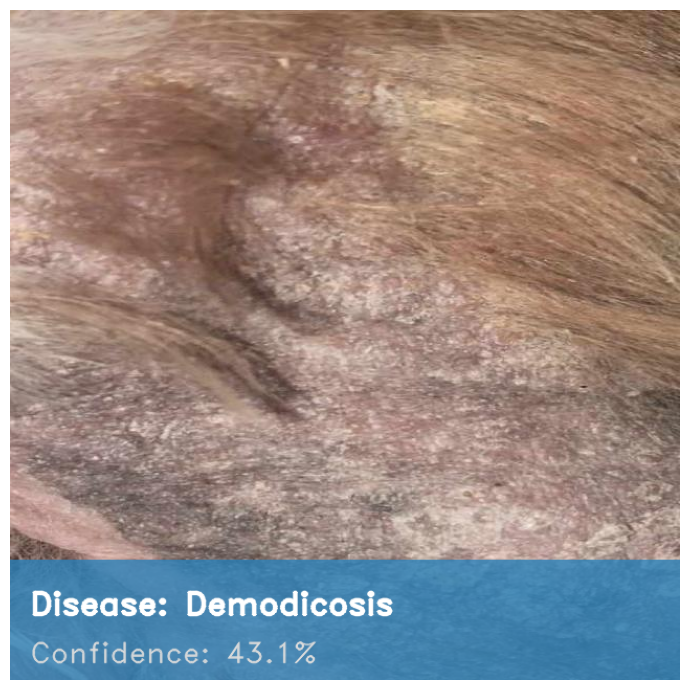

  Predicted : Demodicosis
  Confidence: 43.08%
  ⚠️  Low confidence — consult a vet.


In [9]:
# CELL 5A — Pick image using file browser (no typing needed)
import tkinter as tk
from tkinter import filedialog

root = tk.Tk()
root.withdraw()  # hide the main window
root.attributes('-topmost', True)
img_path = filedialog.askopenfilename(
    title='Select a dog skin image',
    filetypes=[('Image files', '*.jpg *.jpeg *.png *.bmp')]
)
root.destroy()

if img_path:
    print(f'Selected: {img_path}')
    show_prediction(img_path)
else:
    print('No file selected.')

In [9]:
# CELL 5B — Google Colab (uncomment to use)
# from google.colab import files
# uploaded = files.upload()
# img_path = list(uploaded.keys())[0]
# show_prediction(img_path)